# Baseline Diffusion In-Distribution (CIFAR-10 Train/Defend testing)

This is to verify best DDPM training params to use for actual Diffusion models trained Out-of-Distribution

## Narcissus

In [28]:
import pandas as pd
import json
import numpy as np

df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/Poison_Defense/From_Scratch/Narcissus/Results.csv')
df['Args'] = df['Args'].apply(lambda x: json.loads(x))
df = pd.concat([df.drop(['Args'], axis=1), df['Args'].apply(pd.Series)], axis=1)

global_filters = {'noise_eps_narcissus': 16, 
                  }

# Global filters
for key, value in global_filters.items():
    df = df[df[key] == value]

# Defense filters
filters = {'Baseline':{'Data Key': 'Baseline'},
            'JPEG 25':{'Data Key': 'JPEG[25]'},
            # 'JPEG 50':{'Data Key': 'JPEG[50]'},
            # 'JPEG 75':{'Data Key': 'JPEG[75]'},
            # 'JPEG 85':{'Data Key': 'JPEG[85]'},
            # 'EBM-150':{'Data Key': 'EBM[cinic10_imagenet_ep120_nf32]_Steps[150]_T[0.0001]'},
            # 'EBM-300':{'Data Key': 'EBM[cinic10_imagenet_ep120_nf32]_Steps[300]_T[0.0001]'},
            'EBM 500':{'Data Key': 'EBM[cinic10_imagenet_ep120_nf32]_Steps[500]_T[0.0001]'},
            'HF_DDPM-10':{'Data Key': 'HF_DDPM[google_ddpm-cifar10-32]_T[10]'},
            'HF_DDPM-25':{'Data Key': 'HF_DDPM[google_ddpm-cifar10-32]_T[25]'},
            'HF_DDPM-50':{'Data Key': 'HF_DDPM[google_ddpm-cifar10-32]_T[50]'},
            'HF_DDPM-75':{'Data Key': 'HF_DDPM[google_ddpm-cifar10-32]_T[75]'},
            'HF_DDPM-100':{'Data Key': 'HF_DDPM[google_ddpm-cifar10-32]_T[100]'},
            'HF_DDPM-125':{'Data Key': 'HF_DDPM[google_ddpm-cifar10-32]_T[125]'},
            'HF_DDPM-150':{'Data Key': 'HF_DDPM[google_ddpm-cifar10-32]_T[150]'},
            'HF_DDPM-200':{'Data Key': 'HF_DDPM[google_ddpm-cifar10-32]_T[200]'},
}


df_results = []
for label, filter_dict in filters.items():

    df_filt = df
    for key, value in filter_dict.items():
        df_filt = df_filt[df_filt[key] == value]

    df_results.append({'Defense': label,
                        'Nat Acc': f"{df_filt['End Acc'].mean()*100:.2f} \u00B1 {df_filt['End Acc'].std()*100:.2f}",
                        'Poison Success': f"{df_filt['P1 Acc'].mean()*100:.2f} \u00B1 {df_filt['P1 Acc'].std()*100:.2f}",
                        'Max Poison Success': f"{df_filt['P1 Acc'].max()*100:.2f}",
                        'Poisoned Nat Acc': f"{df_filt['T1 Acc'].mean()*100:.2f} \u00B1 {df_filt['T1 Acc'].std()*100:.2f}",
                        'Num Results': len(df_filt),
                    })

df_results = pd.DataFrame(df_results)
df_results

,Defense,Nat Acc,Poison Success,Max Poison Success,Poisoned Nat Acc,Num Results
0,Baseline,92.88 ± 0.17,65.71 ± 16.46,81.52,31.27 ± 14.78,10
1,JPEG 25,88.04 ± 0.19,13.83 ± 13.56,40.54,74.84 ± 10.81,10
2,EBM 500,89.49 ± 0.21,14.72 ± 12.10,39.85,74.38 ± 9.08,10
3,HF_DDPM-10,92.83 ± 0.17,60.09 ± 20.22,79.34,36.02 ± 17.53,10
4,HF_DDPM-25,92.54 ± 0.20,51.34 ± 27.20,88.41,43.38 ± 24.45,10
5,HF_DDPM-50,92.16 ± 0.20,24.14 ± 23.20,69.63,62.89 ± 18.13,10
6,HF_DDPM-75,91.65 ± 0.21,9.37 ± 8.33,26.10,73.28 ± 7.56,10
7,HF_DDPM-100,91.04 ± 0.07,5.79 ± 6.73,23.29,75.11 ± 7.58,10
8,HF_DDPM-125,90.57 ± 0.10,5.20 ± 5.84,20.31,75.69 ± 7.56,10
9,HF_DDPM-150,90.23 ± 0.19,4.32 ± 3.80,12.33,76.11 ± 6.64,10


Text(0.5, 0.98, 'Narcissus Eps-16 Defense Results')

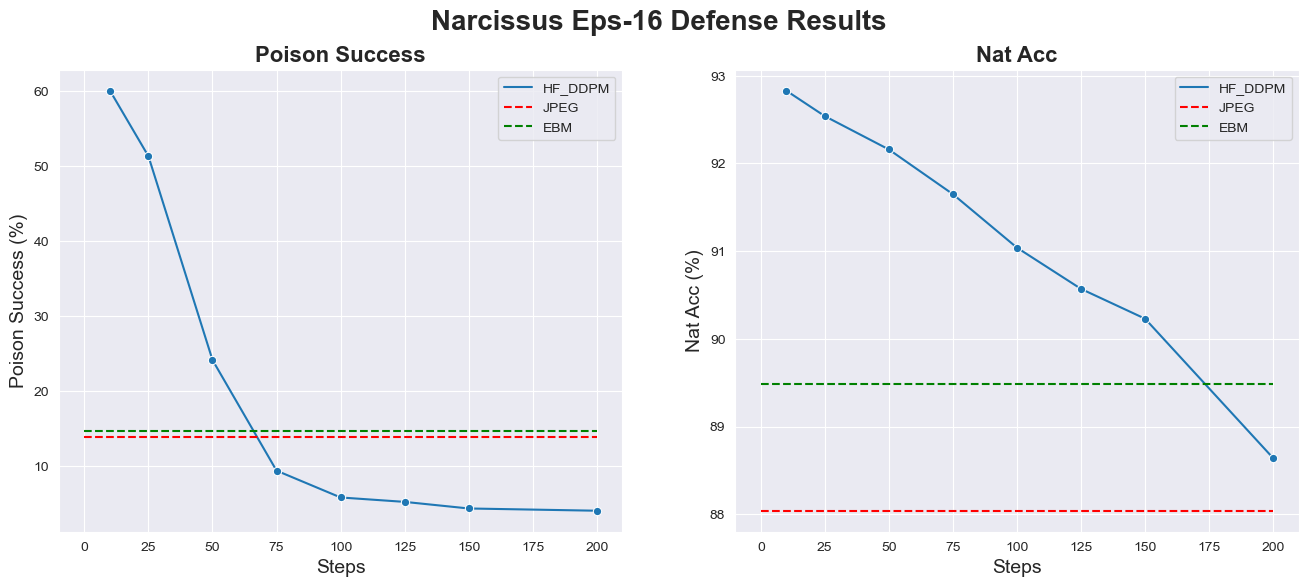

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

dm_plot = df_results.copy()
dm_plot['Label'] = dm_plot['Defense'].apply(lambda x: x.split('-')[0])
dm_plot['Steps'] = dm_plot['Defense'].apply(lambda x: int(x.split('-')[1]) if len(x.split('-')) > 1 else 0)
dm_plot['Nat Acc Mean'] = dm_plot['Nat Acc'].apply(lambda x: float(x.split(' ')[0]))
dm_plot['Poison Success Mean'] = dm_plot['Poison Success'].apply(lambda x: float(x.split(' ')[0]))

# Filter out 0 steps
dm_plot_diff = dm_plot[dm_plot['Steps'] != 0]

# PLot x_axis steps, y axis Nat Acc, and hue as Label
fig,axs = plt.subplots(1, 2, figsize=(16, 6))
sns.lineplot(data=dm_plot_diff, x='Steps', y='Poison Success Mean', hue='Label', marker='o',palette='tab10',ax=axs[0])
sns.lineplot(data=dm_plot_diff, x='Steps', y='Nat Acc Mean', hue='Label', marker='o',palette='tab10',ax=axs[1])

# # Draw Hlines for EBM and JPEG
axs[0].hlines(y=dm_plot[dm_plot['Defense'] == 'JPEG 25']['Poison Success Mean'].values[0], xmin=0, xmax=200, color='r', linestyle='--', label='JPEG')
axs[0].hlines(y=dm_plot[dm_plot['Defense'] == 'EBM 500']['Poison Success Mean'].values[0], xmin=0, xmax=200, color='g', linestyle='--', label='EBM')
axs[0].legend()

axs[1].hlines(y=dm_plot[dm_plot['Defense'] == 'JPEG 25']['Nat Acc Mean'].values[0], xmin=0, xmax=200, color='r', linestyle='--', label='JPEG')
axs[1].hlines(y=dm_plot[dm_plot['Defense'] == 'EBM 500']['Nat Acc Mean'].values[0], xmin=0, xmax=200, color='g', linestyle='--', label='EBM')
axs[1].legend()

# Set titles
axs[0].set_title('Poison Success', fontsize=16, fontweight='bold')
axs[1].set_title('Nat Acc', fontsize=16, fontweight='bold')

# Set x and y labels
axs[0].set_xlabel('Steps', fontsize=14)
axs[0].set_ylabel('Poison Success (%)', fontsize=14)
axs[1].set_xlabel('Steps', fontsize=14)
axs[1].set_ylabel('Nat Acc (%)', fontsize=14)

plt.suptitle('Narcissus Eps-16 Defense Results', fontsize=20, fontweight='bold')

## Neural Tangent (NTG)

In [1]:
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import json
import numpy as np

df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/Poison_Defense/From_Scratch/NeuralTangent/Results.csv')

filters = {'Baseline':{'Data Key': 'Baseline'},
           'JPEG_25':{'Data Key': 'JPEG[25]'},
           'EBM_1000':{'Data Key': 'EBM[cinic10_imagenet_ep120_nf32]_Steps[1000]_T[0.0001]'},
            'HF_DDPM-200':{'Data Key': 'HF_DDPM[google/ddpm-cifar10-32]_T[200]'},
            'HF_DDPM-150':{'Data Key': 'HF_DDPM[google/ddpm-cifar10-32]_T[150]'},
            'HF_DDPM-125':{'Data Key': 'HF_DDPM[google/ddpm-cifar10-32]_T[125]'},
            'HF_DDPM-100':{'Data Key': 'HF_DDPM[google/ddpm-cifar10-32]_T[100]'}, 
            'HF_DDPM-75':{'Data Key': 'HF_DDPM[google/ddpm-cifar10-32]_T[75]'},
            'HF_DDPM-50':{'Data Key': 'HF_DDPM[google/ddpm-cifar10-32]_T[50]'},
            'HF_DDPM-25':{'Data Key': 'HF_DDPM[google/ddpm-cifar10-32]_T[25]'},
            'HF_DDPM-10':{'Data Key': 'HF_DDPM[google/ddpm-cifar10-32]_T[10]'},
            'DDPM[1000]_L-200':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[200]'},
            'DDPM[1000]_L-150':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[150]'},
            'DDPM[1000]_L-125':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[125]'},
            'DDPM[1000]_L-100':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[100]'},
            'DDPM[1000]_L-75':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[75]'},
            'DDPM[1000]_L-50':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[50]'},
            'DDPM[1000]_L-25':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[25]'},
            'DDPM[1000]_L-10':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[L]_ep[200]]_T[10]'},
            'DDPM[1000]_M-200':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[200]'},
            'DDPM[1000]_M-150':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[150]'},
            'DDPM[1000]_M-125':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[125]'},
            'DDPM[1000]_M-100':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[100]'},
            'DDPM[1000]_M-75':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[75]'},
            'DDPM[1000]_M-50':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[50]'},
            'DDPM[1000]_M-25':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[25]'},
            'DDPM[1000]_M-10':{'Data Key': 'DM_UNET[cifar10_DDPM[1000]_nf[M]_ep[150]]_T[10]'},
            'DDPM[750]_L-200':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[200]'},
            'DDPM[750]_L-150':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[150]'},
            'DDPM[750]_L-125':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[125]'},
            'DDPM[750]_L-100':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[100]'},
            'DDPM[750]_L-75':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[75]'},
            'DDPM[750]_L-50':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[50]'},
            'DDPM[750]_L-25':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[25]'},
            'DDPM[750]_L-10':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[L]_ep[175]]_T[10]'},
            'DDPM[750]_M-200':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[200]'},
            'DDPM[750]_M-150':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[150]'},
            'DDPM[750]_M-125':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[125]'},
            'DDPM[750]_M-100':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[100]'},
            'DDPM[750]_M-75':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[75]'},
            'DDPM[750]_M-50':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[50]'},
            'DDPM[750]_M-25':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[25]'},
            'DDPM[750]_M-10':{'Data Key': 'DM_UNET[cifar10_DDPM[750]_nf[M]_ep[150]]_T[10]'},
            'DDPM[500]_L-200':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[200]'},
            'DDPM[500]_L-150':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[150]'},
            'DDPM[500]_L-125':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[125]'},
            'DDPM[500]_L-100':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[100]'},
            'DDPM[500]_L-75':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[75]'},
            'DDPM[500]_L-50':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[50]'},
            'DDPM[500]_L-25':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[25]'},
            'DDPM[500]_L-10':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[L]_ep[175]]_T[10]'},
            'DDPM[500]_M-200':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[150]]_T[200]'},
            'DDPM[500]_M-150':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[150]]_T[150]'},
            'DDPM[500]_M-125':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[150]]_T[125]'},
            'DDPM[500]_M-100':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[150]]_T[100]'},
            'DDPM[500]_M-75':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[150]]_T[75]'},
            'DDPM[500]_M-50':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[150]]_T[50]'},
            'DDPM[500]_M-25':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[150]]_T[25]'},
            'DDPM[500]_M-10':{'Data Key': 'DM_UNET[cifar10_DDPM[500]_nf[M]_ep[150]]_T[10]'},
            'DDPM[250]_L-200':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[200]'},
            'DDPM[250]_L-150':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[150]'},
            'DDPM[250]_L-125':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[125]'},
            'DDPM[250]_L-100':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[100]'},
            'DDPM[250]_L-75':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[75]'},
            'DDPM[250]_L-50':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[50]'},
            'DDPM[250]_L-25':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[25]'},
            'DDPM[250]_L-10':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]_ep[150]]_T[10]'},
            'DDPM[250]_M-200':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[200]'},
            'DDPM[250]_M-150':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[150]'},
            'DDPM[250]_M-125':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[125]'},
            'DDPM[250]_M-100':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[100]'},
            'DDPM[250]_M-75':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[75]'},
            'DDPM[250]_M-50':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[50]'},
            'DDPM[250]_M-25':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[25]'},
            'DDPM[250]_M-10':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[M]_ep[150]]_T[10]'},
            'DDPM[150]_L-200':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[200]'},
            'DDPM[150]_L-150':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[150]'},
            'DDPM[150]_L-125':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[125]'},
            'DDPM[150]_L-100':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[100]'},
            'DDPM[150]_L-75':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[75]'},
            'DDPM[150]_L-50':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[50]'},
            'DDPM[150]_L-25':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[25]'},
            'DDPM[150]_L-10':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[L]_ep[100]]_T[10]'},
            'DDPM[150]_M-200':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]]_T[200]'},
            'DDPM[150]_M-150':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]]_T[150]'},
            'DDPM[150]_M-125':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]]_T[125]'},
            'DDPM[150]_M-100':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]]_T[100]'},
            'DDPM[150]_M-75':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]]_T[75]'},
            'DDPM[150]_M-50':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]]_T[50]'},
            'DDPM[150]_M-25':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]]_T[25]'},
            'DDPM[150]_M-10':{'Data Key': 'DM_UNET[cifar10_DDPM[150]_nf[M]]_T[10]'},
}

df_results = []
for label, filter_dict in filters.items():

    df_filt = df
    for key, value in filter_dict.items():
        if value == 'NaN':
            df_filt = df_filt[df_filt[key].isnull()]
        else:
            df_filt = df_filt[df_filt[key] == value]


    df_results.append({'Defense': label,
                        'Nat Acc': f"{df_filt['End Acc'].mean()*100:.2f} \u00B1 {df_filt['End Acc'].std()*100:.2f}",
                    'Num Results': len(df_filt),
                    })
        
df_results = pd.DataFrame(df_results)
df_results

,Defense,Nat Acc,Num Results
0,Baseline,14.35 ± 1.07,8
1,JPEG_25,77.09 ± 0.54,8
2,EBM_1000,82.67 ± 0.38,8
3,HF_DDPM-200,85.54 ± 0.31,8
4,HF_DDPM-150,87.21 ± 0.16,8
...,...,...,...
86,DDPM[150]_M-100,81.25 ± 0.35,8
87,DDPM[150]_M-75,81.58 ± 0.26,8
88,DDPM[150]_M-50,79.35 ± 0.27,8
89,DDPM[150]_M-25,67.51 ± 0.57,8


In [130]:
df_results[df_results['Num Results'] == 0]

,Defense,Nat Acc,Num Results
51,DDPM[500]_M-200,nan ± nan,0
52,DDPM[500]_M-150,nan ± nan,0
53,DDPM[500]_M-125,nan ± nan,0
54,DDPM[500]_M-100,nan ± nan,0
55,DDPM[500]_M-75,nan ± nan,0
56,DDPM[500]_M-50,nan ± nan,0
57,DDPM[500]_M-25,nan ± nan,0
58,DDPM[500]_M-10,nan ± nan,0
75,DDPM[150]_L-200,nan ± nan,0
76,DDPM[150]_L-150,nan ± nan,0


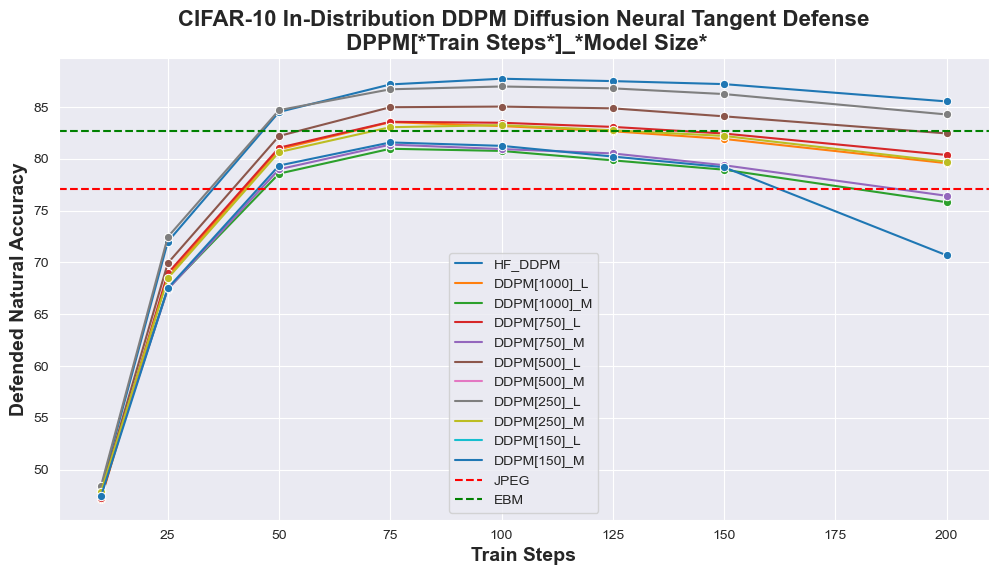

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

dm_plot = df_results.copy()
dm_plot['Label'] = dm_plot['Defense'].apply(lambda x: x.split('-')[0])
dm_plot['Steps'] = dm_plot['Defense'].apply(lambda x: int(x.split('-')[1]) if len(x.split('-')) > 1 else 0)
dm_plot['Nat Acc Mean'] = dm_plot['Nat Acc'].apply(lambda x: float(x.split(' ')[0]))

# Filter out 0 steps
dm_plot_diff = dm_plot[dm_plot['Steps'] != 0]

# PLot x_axis steps, y axis Nat Acc, and hue as Label
plt.figure(figsize=(12, 6))
sns.lineplot(data=dm_plot_diff, x='Steps', y='Nat Acc Mean', hue='Label', marker='o',palette='tab10')

# Draw Hlines for EBM and JPEG
plt.axhline(y=dm_plot[dm_plot['Defense'] == 'JPEG_25']['Nat Acc Mean'].values[0], color='r', linestyle='--', label='JPEG')
plt.axhline(y=dm_plot[dm_plot['Defense'] == 'EBM_1000']['Nat Acc Mean'].values[0], color='g', linestyle='--', label='EBM')

plt.title('CIFAR-10 In-Distribution DDPM Diffusion Neural Tangent Defense\n DPPM[*Train Steps*]_*Model Size*',fontsize=16, fontweight='bold')
plt.xlabel('Train Steps', fontsize=14, fontweight='bold')
plt.ylabel('Defended Natural Accuracy', fontsize=14, fontweight='bold')
plt.legend()

In [132]:
def get_train_steps(x):
    try:
        return int(x.split('[')[1].split(']')[0])
    except:
        return 'HF_DDPM'


dm_plot_diff['Defense'] = dm_plot_diff['Defense'].apply(lambda x: x.split('-')[0])
dm_plot_diff['Size'] = dm_plot_diff['Defense'].apply(lambda x: x.split('_')[1])
dm_plot_diff['Defense'] = dm_plot_diff['Defense'].apply(lambda x: x.split('_')[0])
dm_plot_diff['Train Steps'] = dm_plot_diff['Defense'].apply(get_train_steps)
dm_plot_diff['Purify Steps'] = dm_plot_diff['Steps']
pivot_table = dm_plot_diff.pivot(index=['Size','Train Steps'], columns='Purify Steps', values='Nat Acc')
print(pivot_table.to_latex())

\begin{tabular}{llllllllll}
\toprule
  & Purify Steps &           10  &           25  &           50  &           75  &           100 &           125 &           150 &           200 \\
Size & Train Steps &               &               &               &               &               &               &               &               \\
\midrule
DDPM & HF\_DDPM &  48.18 ± 0.59 &  72.00 ± 0.37 &  84.52 ± 0.38 &  87.18 ± 0.27 &  87.73 ± 0.32 &  87.50 ± 0.37 &  87.21 ± 0.16 &  85.54 ± 0.31 \\
L & 150 &     nan ± nan &     nan ± nan &     nan ± nan &     nan ± nan &     nan ± nan &     nan ± nan &     nan ± nan &     nan ± nan \\
  & 250 &  48.43 ± 0.32 &  72.46 ± 0.35 &  84.70 ± 0.34 &  86.71 ± 0.29 &  86.98 ± 0.28 &  86.80 ± 0.20 &  86.25 ± 0.25 &  84.28 ± 0.45 \\
  & 500 &  47.85 ± 0.51 &  69.93 ± 0.41 &  82.20 ± 0.32 &  84.98 ± 0.39 &  85.04 ± 0.32 &  84.87 ± 0.18 &  84.10 ± 0.15 &  82.45 ± 0.38 \\
  & 750 &  47.30 ± 0.72 &  68.95 ± 0.48 &  81.07 ± 0.34 &  83.57 ± 0.20 &  83.48 ± 0.27 &  8

/var/folders/fc/ctj9qqms3t31k8zg1zz85xwh0000gn/T/ipykernel_21035/1522933308.py:14: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(pivot_table.to_latex())
